In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

In [18]:
import matplotlib.pyplot as plt
sc.settings.figdir="../results/figures"

In [19]:
adata = sc.read_h5ad('../data/raw/GSE131907_Lung_Cancer_raw.h5ad')

In [20]:
adata

AnnData object with n_obs × n_vars = 208506 × 29634

In [21]:
#preserve raw counts first 
adata.layers['counts']=adata.X.copy()

In [22]:
#QC metrics
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata,qc_vars=['mt'],inplace=True)

In [23]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACCTGAGAAACCGC_LN_05,1690,7.433075,19928.0,9.899931,84.017463,87.354476,90.074267,93.692292,43.0,3.784190,0.215777
AAACCTGAGAAACGCC_NS_13,611,6.416732,1382.0,7.232010,55.499276,62.735166,70.260492,91.968162,171.0,5.147494,12.373372
AAACCTGAGAAGGTGA_LUNG_N18,1113,7.015712,3214.0,8.075583,37.678905,53.453640,66.677038,80.927194,106.0,4.672829,3.298071
AAACCTGAGACAAAGG_LUNG_N18,1100,7.003974,2990.0,8.003363,36.254181,51.471572,64.949833,79.933110,133.0,4.897840,4.448161
AAACCTGAGACATAAC_LN_04,948,6.855409,3880.0,8.263848,53.427835,69.948454,79.046392,88.453608,76.0,4.343805,1.958763
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCTTGCCGT_LUNG_T30,2245,7.716906,7981.0,8.984944,41.360732,50.582634,60.593911,73.925573,198.0,5.293305,2.480892
TTTGTCATCTTGTATC_EFFUSION_13,1199,7.090077,4113.0,8.322151,46.146365,61.876975,72.380258,83.005106,114.0,4.744932,2.771699
TTTGTCATCTTTACAC_LUNG_N20,834,6.727432,1979.0,7.590852,38.706417,52.956038,65.891865,83.122789,97.0,4.584968,4.901465
TTTGTCATCTTTACAC_LUNG_T25,921,6.826545,3342.0,8.114624,49.670856,66.277678,76.810293,87.402753,94.0,4.553877,2.812687


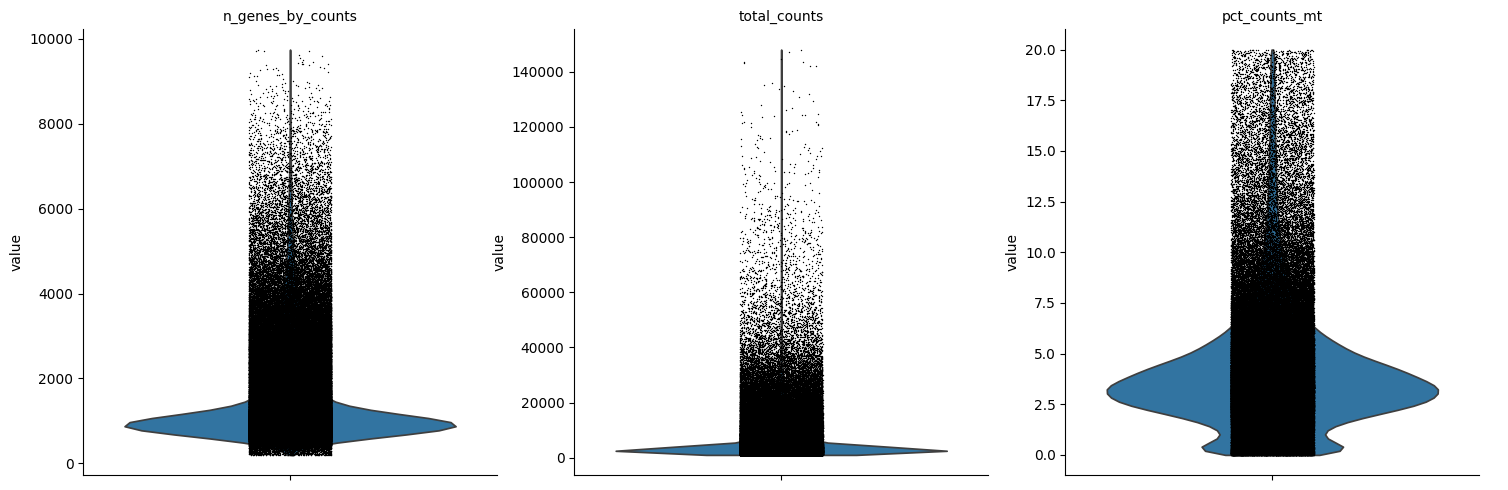

In [24]:
#visualization before filtering 
sc.pl.violin(adata,['n_genes_by_counts','total_counts','pct_counts_mt'],multi_panel=True,save='_qc_before_filtering.png')

In [25]:
#filtering 
sc.pp.filter_cells(adata,min_genes=200)
adata=adata[adata.obs['n_genes_by_counts']<7000,:].copy()
adata=adata[adata.obs['pct_counts_mt']<10,:].copy()
sc.pp.filter_genes(adata,min_cells=3)

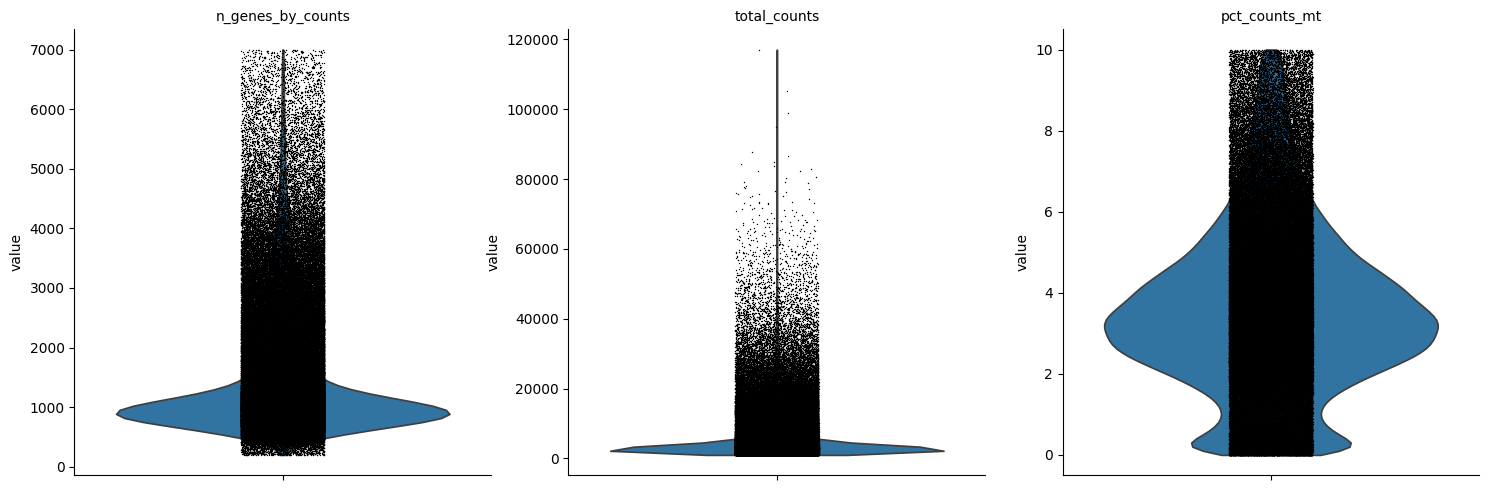

In [26]:
#After filtering 
sc.pl.violin(adata,['n_genes_by_counts','total_counts','pct_counts_mt'],multi_panel=True,save='_qc_after_filtering.png')

In [27]:
adata.write("../data/processed/nsclc_qc.h5ad")